In [9]:
import numpy as np
import re
import matplotlib.pyplot as plt
from itertools import groupby

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter
from qiskit_aer import AerSimulator

State awal |↑↓↓⟩: [0 0 0 1 0 0 0 0]

Initial state circuit:
          
q_0: ─────
     ┌───┐
q_1: ┤ X ├
     ├───┤
q_2: ┤ X ├
     └───┘

Menjalankan Hadamard Test (50 steps × 2 circuit)...
  Step 0/50
  Step 10/50
  Step 20/50
  Step 30/50
  Step 40/50


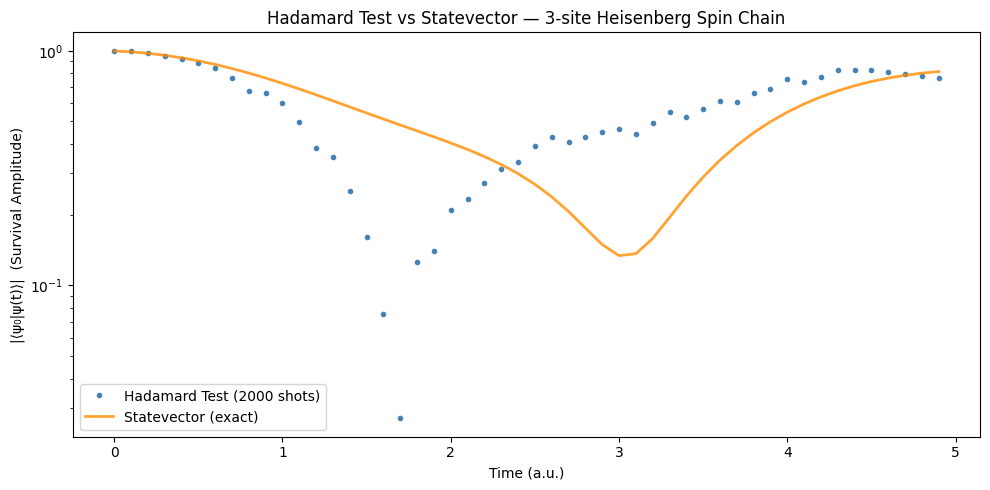


Mean Absolute Error (Hadamard vs Statevector): 0.1742
(Turunkan error dengan menaikkan num_shots)


In [10]:
# ============================================================
# Section 4.5 — Hadamard Test (SELF-CONTAINED)
# Semua dependensi didefinisikan ulang di sini
# ============================================================

# ── Parameter sistem (dari Section 4.4) ──────────────────────
num_q              = 3
evolution_timestep = 0.1
n_trotter_steps    = 1

# Koefisien Hamiltonian dari Table 1 paper: [XX/2, YY/2, ZZ, Z]
ham_coeffs = (
    [[0.75/2, 0.75/2, 0.0, 0.65]]           # site 0
    + [[0.5, 0.5, 0.0, 1.0]] * (num_q - 1)  # site 1, 2
)

# ── Rebuild Hamiltonian ───────────────────────────────────────
def get_hamiltonian_n_site_terms(n, coeff, n_qubits):
    XX = SparsePauliOp('I'*n + 'XX' + 'I'*(n_qubits-2-n)) * coeff[0]
    YY = SparsePauliOp('I'*n + 'YY' + 'I'*(n_qubits-2-n)) * coeff[1]
    ZZ = SparsePauliOp('I'*n + 'ZZ' + 'I'*(n_qubits-2-n)) * coeff[2]
    Z  = SparsePauliOp('I'*n + 'Z'  + 'I'*(n_qubits-1-n)) * coeff[3]
    return (XX + YY + ZZ + Z).simplify()

def get_heisenberg_hamiltonian(n_qubits, coeff=None):
    assert n_qubits >= 3
    if coeff is None:
        coeff = [[1.0, 1.0, 1.0, 1.0] for _ in range(n_qubits)]
    H_E = sum(get_hamiltonian_n_site_terms(i, coeff[i], n_qubits)
              for i in range(0, n_qubits-1, 2))
    H_O = sum(get_hamiltonian_n_site_terms(i, coeff[i], n_qubits)
              for i in range(1, n_qubits-1, 2))
    final_term = SparsePauliOp('I'*(n_qubits-1) + 'Z') * coeff[n_qubits-1][3]
    if n_qubits % 2 == 0:
        H_E = (H_E + final_term).simplify()
    else:
        H_O = (H_O + final_term).simplify()
    return [H_E, H_O]

def get_time_evolution_operator(num_qubits, tau, trotter_steps, coeff=None):
    H = get_heisenberg_hamiltonian(num_qubits, coeff)
    evo_op = PauliEvolutionGate(
        H, tau,
        synthesis=SuzukiTrotter(order=2, reps=trotter_steps)
    )
    return evo_op.definition

# Bangun time evolution operator
time_evo_op = get_time_evolution_operator(
    num_qubits=num_q,
    tau=evolution_timestep,
    trotter_steps=n_trotter_steps,
    coeff=ham_coeffs
)

# ── State awal |↑↓↓⟩ = |011⟩ ─────────────────────────────────
zero_state = np.array([[1], [0]])
one_state  = np.array([[0], [1]])
psin0 = zero_state
for _ in range(num_q - 1):
    psin0 = np.kron(psin0, one_state)
psin0 = psin0.flatten()
print(f"State awal |↑↓↓⟩: {np.round(psin0, 4)}")

# ── Helper functions Hadamard Test ────────────────────────────
def get_hadamard_test(num_q, initial_state_circ, control_operation,
                      control_repeats=0, imag_expectation=False):
    """
    Bangun circuit Hadamard Test untuk ⟨ψ|U^k|ψ⟩.
    
    Struktur:
    - qubit 0       : ancilla (detektor interferensi)
    - qubit 1..num_q: system qubits (state fisik)
    
    Pengukuran ancilla → Re atau Im dari ⟨ψ|U^k|ψ⟩
    """
    qr_h = QuantumRegister(num_q + 1, name='q')
    cr_h = ClassicalRegister(1, name='anc')
    qc_h = QuantumCircuit(qr_h, cr_h)

    # Init system qubits dengan state |ψ₀⟩
    qc_h.append(initial_state_circ, qr_h[1:])
    qc_h.barrier()

    # Hadamard pada ancilla: |0⟩ → (|0⟩+|1⟩)/√2
    qc_h.h(0)

    # Untuk bagian imajiner: tambahkan S† = P(-π/2)
    if imag_expectation:
        qc_h.p(-np.pi / 2, 0)

    # Controlled-U diaplikasikan k kali
    for _ in range(control_repeats):
        qc_h.append(control_operation, qr_h[:])

    # Hadamard kedua lalu ukur ancilla
    qc_h.h(0)
    qc_h.barrier()
    qc_h.measure(0, 0)
    return qc_h


def get_spin_correlation(counts):
    """
    Konversi counts → expectation value.
    |0⟩ → eigenvalue +1,  |1⟩ → eigenvalue -1
    ⟨σz⟩ = (N₀ - N₁) / (N₀ + N₁)
    """
    spin_map = {'0': +1, '1': -1}
    total  = sum(counts.values())
    value  = sum(spin_map[k] * v for k, v in counts.items())
    return value / total


def get_circuit_execution_counts(qc, simulator, n_shots=1000):
    """Jalankan circuit dan kembalikan counts. Qiskit 2.x API."""
    qc_t   = transpile(qc, simulator)
    result = simulator.run(qc_t, shots=n_shots).result()
    return result.get_counts()


# ── Setup circuit initial state ───────────────────────────────
# Buat circuit yang mengatur state |011⟩ (untuk di-append ke Hadamard circuit)
qr_init   = QuantumRegister(num_q, name='q')
init_circ = QuantumCircuit(qr_init)
for i in range(num_q):
    if i != 0:
        init_circ.x(i)   # flip qubit 1 dan 2 → spin-down

print("\nInitial state circuit:")
print(init_circ.draw(output='text'))

# ── Controlled time evolution operator ───────────────────────
# .control() → tambah 1 control qubit (ancilla) di depan
controlled_time_evo_op = time_evo_op.control()

# ── Jalankan Hadamard Test ─────────────────────────────────────
qasm_sim  = AerSimulator(method='statevector')
num_shots  = 2000
n_had_steps = 50   # jumlah timestep yang diukur
time_range  = np.arange(n_had_steps) * evolution_timestep

real_amp_list = []
imag_amp_list = []

print(f"\nMenjalankan Hadamard Test ({n_had_steps} steps × 2 circuit)...")
for idx in range(n_had_steps):
    if idx % 10 == 0:
        print(f"  Step {idx}/{n_had_steps}")

    # Bagian Real: ⟨ψ₀|U^k|ψ₀⟩ real
    qc_real = get_hadamard_test(
        num_q, init_circ, controlled_time_evo_op,
        control_repeats=idx, imag_expectation=False
    )
    counts_real = get_circuit_execution_counts(qc_real, qasm_sim, num_shots)
    real_amp_list.append(get_spin_correlation(counts_real))

    # Bagian Imajiner: ⟨ψ₀|U^k|ψ₀⟩ imag
    qc_imag = get_hadamard_test(
        num_q, init_circ, controlled_time_evo_op,
        control_repeats=idx, imag_expectation=True
    )
    counts_imag = get_circuit_execution_counts(qc_imag, qasm_sim, num_shots)
    imag_amp_list.append(get_spin_correlation(counts_imag))

# ── Hitung Survival Amplitude ─────────────────────────────────
real_arr    = np.array(real_amp_list)
imag_arr    = np.array(imag_amp_list)
sa_hadamard = np.abs(real_arr + 1j * imag_arr)

# ── Benchmark: statevector eksak ──────────────────────────────
def qsolve_statevector(psin_arr, time_evo_circuit):
    d    = int(np.log2(len(psin_arr)))
    qre  = QuantumRegister(d)
    circ = QuantumCircuit(qre)
    circ.prepare_state(psin_arr.tolist(), qre)
    circ.barrier()
    circ.append(time_evo_circuit, qre)
    return np.array(Statevector(circ))

psin_sv   = psin0.copy()
sa_sv     = []
for k in range(n_had_steps):
    psin_sv = qsolve_statevector(psin_sv, time_evo_op)
    sa_sv.append(np.abs(np.vdot(psin_sv, psin0)))

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_range, sa_hadamard, '.', ms=6,
        label=f'Hadamard Test ({num_shots} shots)', color='steelblue')
ax.plot(time_range, sa_sv, '-', lw=2,
        label='Statevector (exact)', color='darkorange', alpha=0.8)
ax.set_xlabel('Time (a.u.)')
ax.set_ylabel('|⟨ψ₀|ψ(t)⟩|  (Survival Amplitude)')
ax.set_yscale('log')
ax.set_title(f'Hadamard Test vs Statevector — {num_q}-site Heisenberg Spin Chain')
ax.legend()
plt.tight_layout()
plt.show()

# Statistik perbandingan
mae = np.mean(np.abs(sa_hadamard - np.array(sa_sv)))
print(f"\nMean Absolute Error (Hadamard vs Statevector): {mae:.4f}")
print(f"(Turunkan error dengan menaikkan num_shots)")